# Trajetória Radial

In [1]:
!pip install -q fastmri torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 1.3 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.8 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import torch.nn.functional as F
import glob, h5py

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
def radial_mask(H, W, num_lines=30):

    mask = np.zeros((H, W), dtype=np.float32)

    center_y, center_x = H // 2, W // 2

    angles = np.linspace(0, np.pi, num_lines)

    for angle in angles:
        for r in range(-max(H, W), max(H, W)):

            y = int(center_y + r * np.sin(angle))
            x = int(center_x + r * np.cos(angle))

            if 0 <= y < H and 0 <= x < W:
                mask[y, x] = 1

    return mask

In [4]:
class DatasetMRI(Dataset):

    def __init__(self, root):
        self.files = glob.glob(root + '/**/*.h5', recursive=True)
        print("Arquivos:", len(self.files))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        with h5py.File(self.files[idx], 'r') as f:
            kspace = f['kspace'][()]
            slice_idx = np.random.randint(0, kspace.shape[0])
            kspace = kspace[slice_idx]

        kspace = torch.tensor(kspace, dtype=torch.complex64)
        kspace = torch.view_as_real(kspace).float()

        Nc, H, W, _ = kspace.shape

        mask_np = radial_mask(H, W)

        mask = torch.tensor(mask_np).unsqueeze(0).unsqueeze(-1)
        mask = mask.repeat(Nc, 1, 1, 2)

        kspace_us = kspace * mask

        return kspace_us, kspace, torch.tensor(mask_np)

In [5]:
def fft2c(x):
    return torch.fft.fft2(x)

def ifft2c(x):
    return torch.fft.ifft2(x)

In [6]:
def to_image(k):

    k = torch.view_as_complex(k)

    img = torch.abs(torch.fft.ifft2(k))

    img = torch.sqrt((img**2).sum(dim=1)).unsqueeze(1)

    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    return img

In [7]:
T = 50

beta = torch.linspace(1e-4, 0.02, T).to(device)
alpha = 1 - beta
alpha_bar = torch.cumprod(alpha, 0)

In [8]:
def forward_diffusion(x0, t):

    noise = torch.randn_like(x0)

    a = alpha_bar[t].view(-1,1,1,1)

    return torch.sqrt(a)*x0 + torch.sqrt(1-a)*noise, noise

In [9]:
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(2, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 1, 3, padding=1)
        )

    def forward(self, x, t):
        return self.net(x)

In [10]:
def loss_fn(model, x0, x_cond):

    t = torch.randint(0, T, (x0.shape[0],), device=device)

    xt, noise = forward_diffusion(x0, t)

    inp = torch.cat([xt, x_cond], dim=1)

    pred = model(inp, t)

    return ((pred - noise)**2).mean()

In [11]:
train_path = '/kaggle/input/datasets/arafatshovon/fastmri-knee-multicoil'

dataset = DatasetMRI(train_path)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

Arquivos: 194


In [12]:
model = UNet().to(device)
opt = torch.optim.Adam(model.parameters(), 1e-4)

data_iter = iter(loader)

for step in range(3000):

    try:
        kus, kgt, mask = next(data_iter)
    except StopIteration:
        data_iter = iter(loader)
        kus, kgt, mask = next(data_iter)

    kus, kgt = kus.to(device), kgt.to(device)

    img_gt = to_image(kgt)
    img_us = to_image(kus)

    loss = loss_fn(model, img_gt, img_us)

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % 100 == 0:
        print(f"Step {step} | Loss {loss.item():.4f}")

    if step % 500 == 0:
        torch.save({
            'model': model.state_dict(),
            'opt': opt.state_dict(),
            'step': step
        }, f'/kaggle/working/ckpt_{step}.pth')

Step 0 | Loss 0.9994
Step 100 | Loss 0.1680
Step 200 | Loss 0.0356
Step 300 | Loss 0.0397
Step 400 | Loss 0.0872
Step 500 | Loss 0.0404
Step 600 | Loss 0.0474
Step 700 | Loss 0.0306
Step 800 | Loss 0.0380
Step 900 | Loss 0.0340
Step 1000 | Loss 0.0244
Step 1100 | Loss 0.0455
Step 1200 | Loss 0.0468
Step 1300 | Loss 0.0204
Step 1400 | Loss 0.0182
Step 1500 | Loss 0.0202
Step 1600 | Loss 0.0836
Step 1700 | Loss 0.0760
Step 1800 | Loss 0.0257
Step 1900 | Loss 0.0175
Step 2000 | Loss 0.0257
Step 2100 | Loss 0.0157
Step 2200 | Loss 0.0425
Step 2300 | Loss 0.0507
Step 2400 | Loss 0.0440
Step 2500 | Loss 0.0182
Step 2600 | Loss 0.0165
Step 2700 | Loss 0.0156
Step 2800 | Loss 0.0340
Step 2900 | Loss 0.0696


In [13]:
@torch.no_grad()
def sample(model, us_img, mask):

    x = torch.randn_like(us_img).to(device)

    mask = mask.unsqueeze(0).unsqueeze(0).float()
    mask = F.interpolate(mask, size=us_img.shape[-2:], mode='nearest').to(device)

    for t in reversed(range(T)):

        t_tensor = torch.tensor([t], device=device)

        pred = model(torch.cat([x, us_img], dim=1), t_tensor)

        a = alpha[t]
        ab = alpha_bar[t]

        x = (1/torch.sqrt(a)) * (x - (1-a)/torch.sqrt(1-ab) * pred)

        k = fft2c(x.squeeze(1))
        kus = fft2c(us_img.squeeze(1))

        k = mask.squeeze(1) * kus + (1-mask.squeeze(1)) * k

        x = torch.real(ifft2c(k)).unsqueeze(1)

    return x

In [14]:
kus, kgt, mask = next(iter(loader))

kus = kus.to(device)
kgt = kgt.to(device)

img_us = to_image(kus)
img_gt = to_image(kgt)

rec = sample(model, img_us, mask[0])

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

print("PSNR:", psnr_metric(rec, img_gt).item())
print("SSIM:", ssim_metric(rec, img_gt).item())

PSNR: 22.275724411010742
SSIM: 0.5393063426017761


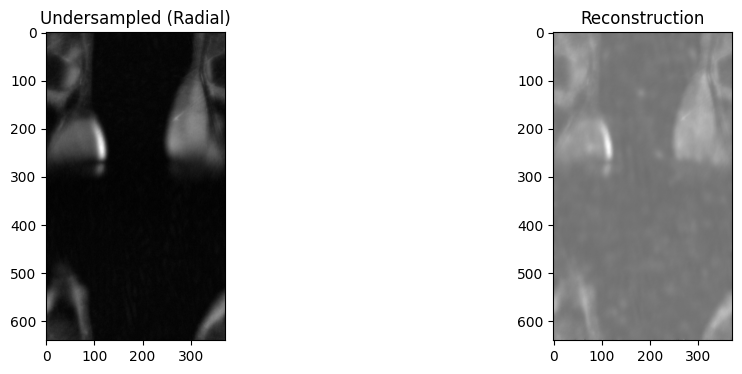

In [15]:
rec = rec.cpu()
img_us = img_us.cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(img_us[0,0], cmap='gray')
plt.title('Undersampled (Radial)')

plt.subplot(1,2,2)
plt.imshow(rec[0,0], cmap='gray')
plt.title('Reconstruction')

plt.show()